# EDA 4CH2: Energy Surface Analysis

This notebook performs exploratory data analysis for the 4CH2 system by calculating energies across wide ranges of Jintra and deltaJ parameters and visualizing the smoothness of energy surfaces.

## Objectives
1. Calculate energies for comprehensive parameter grids
2. Visualize energy surfaces using heatmaps and contour plots
3. Analyze smoothness and identify any discontinuities
4. Create cross-sectional analysis for detailed inspection

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import ndimage
from tqdm import tqdm
import sys
import os

# Add the parent directory to the path to import nmrkan modules
if os.path.abspath(os.path.join(os.getcwd(), '..')) not in sys.path:
    sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# Import the energy calculation function
from data_generation.eigenvalues_4CH2 import CalcEigenEnergies, get_surfaces_vectors_in_region
from data_generation.datasets import make_normalized_eigenvalue_dataset
# Import training components from the new unified framework
from nmrkan import KharKAN, SingleOutputTrainer, TrainingConfig, ModelConfig, DataConfig
from nmrkan.data import DatasetFactory
import torch
from torch.utils.data import DataLoader, TensorDataset

# Set up plotting parameters
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
sns.set_palette("viridis")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
dataset=make_normalized_eigenvalue_dataset(10000)

Computing high-resolution eigenvalue surfaces (200x200)...
Surface computation complete. Ready for fast interpolation.
Generating 10000 samples with efficient surface interpolation...
Dataset generation complete. Shape: input (10000, 1), output (10000, 8)


In [3]:
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([10000, 1]), torch.Size([10000, 8]))

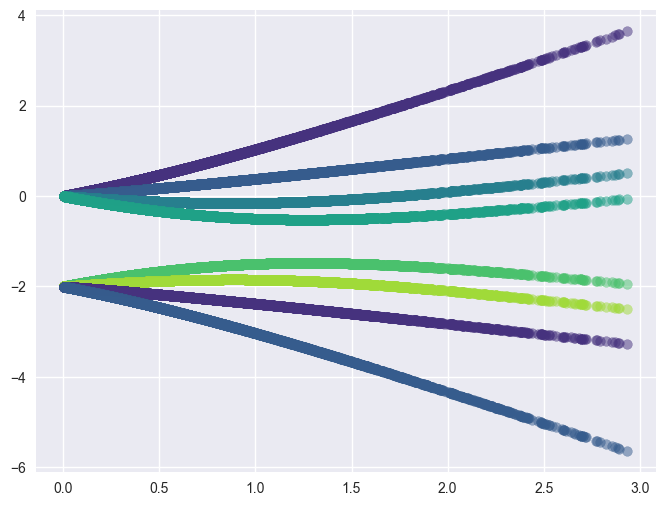

In [4]:
plt.figure(figsize=(8, 6))
for i in range(8):
    plt.scatter(dataset['train_input'][...,0], dataset['train_label'][...,i], alpha=0.5)
#for i in range(1):
#plt.plot(np.sort(dataset['train_input'][...,0]), pred_z0(np.sort(dataset['train_input'][...,0])), color='red', linewidth=2)

# Train KAN Model

Now we'll train a KAN model with 3 layers to predict the 8 normalized eigenvalues from the deltaJ/Jintra ratio.

In [5]:
# Set up device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# Prepare data for training
# Extract input (deltaJ/Jintra ratio) and outputs (8 normalized eigenvalues)
X = dataset['train_input'][:, 0:1]  # deltaJ/Jintra ratio (keep as 2D)
y = dataset['train_label']  # 8 normalized eigenvalues

# Convert to tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)


In [6]:
# Configure the KAN model with 3 layers: 1 input -> hidden -> 8 outputs
model_config = ModelConfig(
    layers=(1, 10, 8),  # 3-layer architecture: 1 input, 10 hidden, 8 outputs
    linear_bias=True,
    include_abs=False,
)

# Configure training parameters
training_config = TrainingConfig(
    epochs=5000,  # Shorter training for notebook
    learning_rate=1e-3,
    batch_size=8000,
    l05_penalty=0.1,
    early_stopping_threshold=1e-5,
    early_stopping_patience=500,
    log_interval=500
    
)

print("Model configuration:")
print(f"  Architecture: {model_config.layers}")
print(f"  Training epochs: {training_config.epochs}")
print(f"  Learning rate: {training_config.learning_rate}")
print(f"  Batch size: {training_config.batch_size}")

Model configuration:
  Architecture: (1, 10, 8)
  Training epochs: 5000
  Learning rate: 0.001
  Batch size: 8000


In [7]:
# Create data loaders
dataset_tensor = TensorDataset(X_tensor, y_tensor)
total_size = len(dataset_tensor)
train_size = int(0.8 * total_size)
val_size = total_size - train_size

# Split dataset
train_dataset, val_dataset = torch.utils.data.random_split(
    dataset_tensor, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Create loaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=training_config.batch_size, 
    shuffle=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=training_config.batch_size, 
    shuffle=False
)


In [8]:
# Initialize and train the KAN model
trainer = SingleOutputTrainer(
    training_config=training_config,
    model_config=model_config,
    device=device,
    experiment_dir=None  # Don't save checkpoints in notebook
)

print("Starting training...")
print("="*50)

# Train the model
kan_model = trainer.train(train_loader, val_loader)

print("="*50)
print("Training completed!")

Starting training...
Starting single output training...
Model architecture: (1, 10, 8)
Training on device: cuda


Training:   0%|          | 1/5000 [00:00<22:37,  3.68it/s, Train MSE=2.296467, Val MSE=2.298082, Best Val=2.298082]

Epoch 1: MSE=2.304022, L0.5=8.052558, Total=3.109278


Training:  10%|█         | 500/5000 [00:58<12:22,  6.06it/s, Train MSE=0.023913, Val MSE=0.024299, Best Val=0.024299]

Epoch 500: MSE=0.023913, L0.5=7.613474, Total=0.785260


...

Epoch 4000: MSE=0.000088, L0.5=1.208448, Total=0.120933


Training:  90%|█████████ | 4501/5000 [10:10<00:55,  9.04it/s, Train MSE=0.000136, Val MSE=0.000124, Best Val=0.000071]

Epoch 4500: MSE=0.000067, L0.5=0.928714, Total=0.092938

Switched to sparsemax at epoch 4500/5000


Training: 100%|██████████| 5000/5000 [11:10<00:00,  7.46it/s, Train MSE=0.000058, Val MSE=0.000062, Best Val=0.000062]


Epoch 5000: MSE=0.000058, L0.5=0.000000, Total=0.000058
Training plots saved to: experiment_results\unified_experiments_1771156105\training_curves.png

Training completed! Best validation MSE: 0.000062
Results saved to: experiment_results\unified_experiments_1771156105
Training completed!


In [9]:
# Evaluate the trained model
kan_model.eval()

# Generate predictions on test data
with torch.no_grad():
    X_test = X_tensor.to(device)
    y_pred = kan_model(X_test).cpu().numpy()
    y_true = y_tensor.numpy()

# Calculate performance metrics
mse = np.mean((y_pred - y_true)**2)
mae = np.mean(np.abs(y_pred - y_true))
r2_scores = []

for i in range(8):
    # R² score for each output
    ss_res = np.sum((y_true[:, i] - y_pred[:, i]) ** 2)
    ss_tot = np.sum((y_true[:, i] - np.mean(y_true[:, i])) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    r2_scores.append(r2)

print("Model Performance:")
print(f"  Overall MSE: {mse:.6f}")
print(f"  Overall MAE: {mae:.6f}")
print(f"  Average R²: {np.mean(r2_scores):.4f}")
print("\nPer-output R² scores:")
for i, r2 in enumerate(r2_scores):
    print(f"  Output {i+1}: {r2:.4f}")

Model Performance:
  Overall MSE: 0.000059
  Overall MAE: 0.004502
  Average R²: 0.9965

Per-output R² scores:
  Output 1: 0.9997
  Output 2: 0.9998
  Output 3: 0.9918
  Output 4: 0.9947
  Output 5: 0.9947
  Output 6: 0.9918
  Output 7: 0.9998
  Output 8: 0.9997


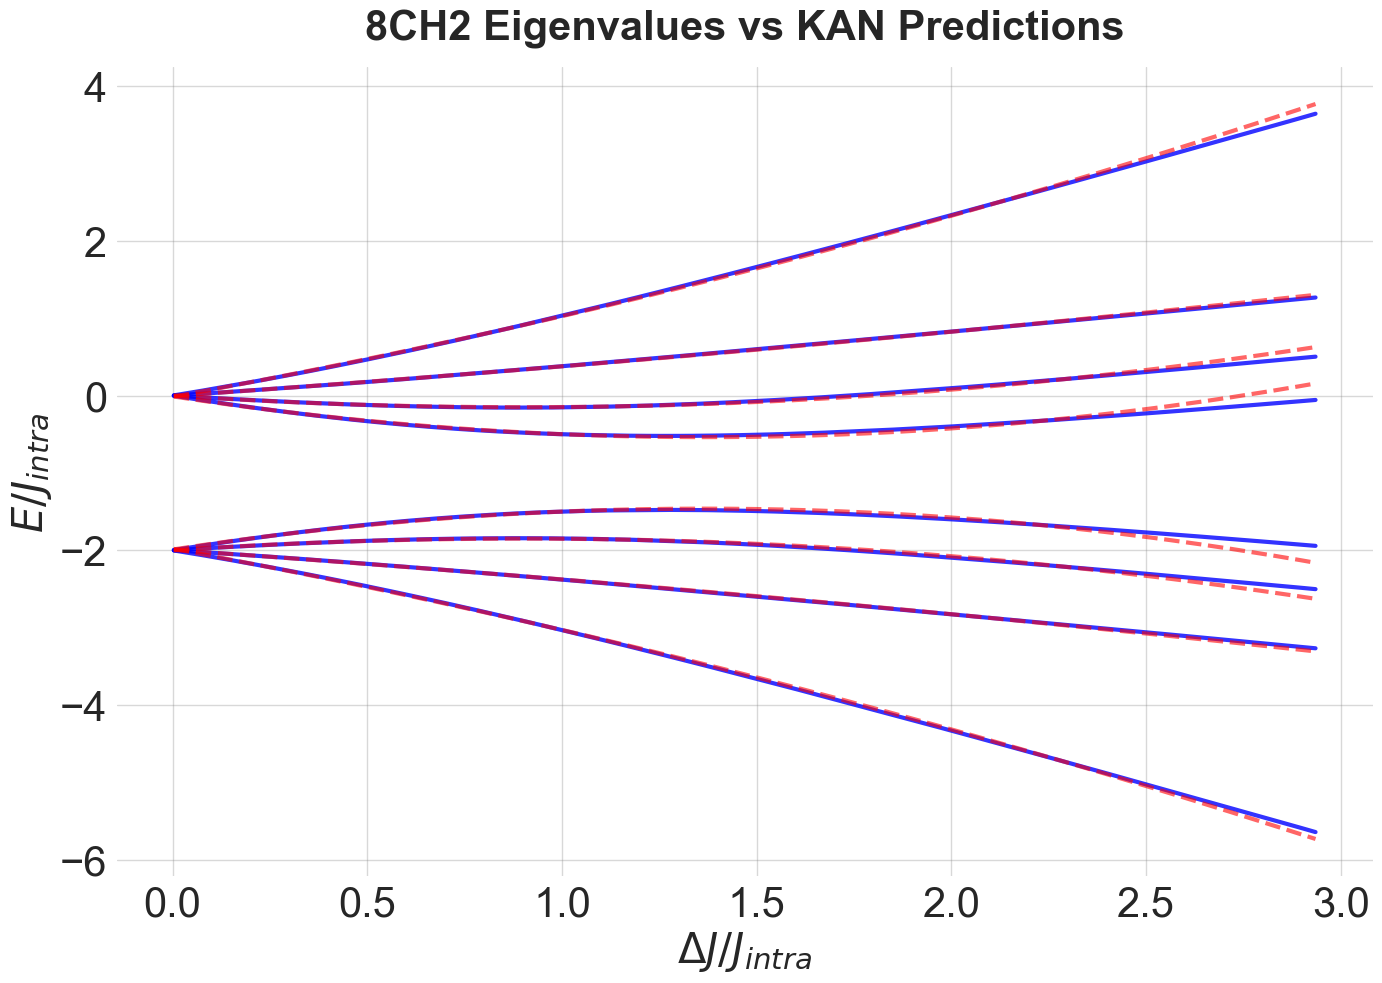

Average R² Score: 0.9965
MSE: 5.92e-05
MAE: 4.50e-03


In [10]:
# Create a single combined plot with all 8 eigenvalues and KAN predictions
sns.set_style("whitegrid")
plt.figure(figsize=(14, 10))

# Sort data by input ratio for better visualization
sort_idx = np.argsort(X.flatten())
X_sorted = X.flatten()[sort_idx]
y_true_sorted = y_true[sort_idx]
y_pred_sorted = y_pred[sort_idx]

# Define colors for eigenvalues and predictions
eigenvalue_color = 'blue'
prediction_color = 'red'

# Plot all eigenvalues in blue
for i in range(8):
    plt.plot(X_sorted, y_true_sorted[:, i], color=eigenvalue_color, 
             linewidth=3, alpha=0.8)

# Plot all KAN predictions in red
for i in range(8):
    plt.plot(X_sorted, y_pred_sorted[:, i], color=prediction_color, 
             linewidth=3, alpha=0.6, linestyle='--')

plt.xlabel(r'$\Delta J / J_{intra}$', fontsize=30, fontweight='bold')
plt.ylabel(r'$E / J_{intra}$', fontsize=30, fontweight='bold')
plt.title('8CH2 Eigenvalues vs KAN Predictions', fontsize=30, fontweight='bold', pad=20)

# Customize tick labels
plt.tick_params(axis='both', which='major', labelsize=30)

# Customize grid
plt.grid(True, color='gray', linestyle='-', alpha=0.3)
plt.gca().set_axisbelow(True)
plt.gca().set_facecolor('none')

# Create simple 2-entry legend
eigenvalue_legend = plt.Line2D([0], [0], color=eigenvalue_color, linewidth=2, 
                               label='Eigenvalues')
prediction_legend = plt.Line2D([0], [0], color=prediction_color, linewidth=2, 
                              linestyle='--', label='KAN Predictions')

#plt.legend(handles=[eigenvalue_legend, prediction_legend], 
#          loc='center left', bbox_to_anchor=(1, 0.5), fontsize=14)

# Performance summary text
avg_r2 = np.mean(r2_scores)
#plt.text(0.02, 0.98, f'Avg R² = {avg_r2:.4f}\nMSE = {mse:.2e}', 
#         transform=plt.gca().transAxes, fontsize=30, 
#         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('EDA_4CH2_KAN_vs_Eigenvalues.pdf', bbox_inches='tight', dpi=300)
plt.show()

print(f"Average R² Score: {avg_r2:.4f}")
print(f"MSE: {mse:.2e}")
print(f"MAE: {mae:.2e}")

In [11]:
# Extract symbolic formulas from the trained KAN model
from nmrkan.analysis import FormulaExtractor

# Create formula extractor
formula_extractor = FormulaExtractor(
    models=kan_model,
    input_names=['deltaJ_ratio'],
    output_names=[f'eigenval_{i}' for i in range(8)]
)

# Extract formulas
print("Extracting symbolic formulas from trained KAN model...")
formulas = formula_extractor.extract_formulas(clean=True, round_digits=3)

# Display the formulas
print("\nSymbolic Formulas:")
print("="*60)

for model_key, model_formulas in formulas.items():
    for output_name, expr in model_formulas.items():
        print(f"{output_name}: {expr}")
    print()

# Calculate complexity metrics
complexity = formula_extractor.calculate_complexity(formulas)

print("Formula Complexity Metrics:")
print("="*60)
for model_key, model_metrics in complexity.items():
    for output_name, metrics in model_metrics.items():
        print(f"{output_name}:")
        print(f"  Terms: {metrics['num_terms']}")
        print(f"  Operations: {metrics['num_operations']}")
        print(f"  Max Degree: {metrics['max_degree']}")
        print(f"  Variables: {metrics['num_variables']}")
        print()

Extracting symbolic formulas from trained KAN model...

Symbolic Formulas:
eigenval_0: 0.128*deltaJ_ratio**2 + 0.915*deltaJ_ratio - 0.016
eigenval_1: 0.032*deltaJ_ratio**2 + 0.351*deltaJ_ratio - 0.006
eigenval_2: deltaJ_ratio*(0.188*deltaJ_ratio - 0.337)
eigenval_3: 0.282*deltaJ_ratio**2 - 0.772*deltaJ_ratio - 0.01
eigenval_4: -0.284*deltaJ_ratio**2 + 0.775*deltaJ_ratio - 1.991
eigenval_5: -0.188*deltaJ_ratio**2 + 0.338*deltaJ_ratio - 2.001
eigenval_6: -0.034*deltaJ_ratio**2 - 0.349*deltaJ_ratio - 1.995
eigenval_7: -0.118*deltaJ_ratio**2 - 0.933*deltaJ_ratio - 1.979

Formula Complexity Metrics:
eigenval_0:
  Terms: 3
  Operations: 4
  Max Degree: 2
  Variables: 1

eigenval_1:
  Terms: 3
  Operations: 4
  Max Degree: 2
  Variables: 1

eigenval_2:
  Terms: 1
  Operations: 3
  Max Degree: 2
  Variables: 1

eigenval_3:
  Terms: 3
  Operations: 4
  Max Degree: 2
  Variables: 1

eigenval_4:
  Terms: 3
  Operations: 4
  Max Degree: 2
  Variables: 1

eigenval_5:
  Terms: 3
  Operations: 4
  Ma